# Helpful Code Note: Analyzing Phyphox Data in Python

You will export your trial from Phyphox as **"Raw Data.csv"**. The file is **tab-separated** and the **first line is a header** (column names):

`time (s) [tab] ax [tab] ay [tab] az [tab] |a|`

The script below automatically extracts the header and selects the **y-axis** column (assuming that axis was aligned with motion).  
If your phone was oriented differently, you can adjust the axis by searching for `"x"` or `"z"` instead.

---

## Step 1. Import the data
`import pandas as pd`  
`import numpy as np`  
`import matplotlib.pyplot as plt`  

`filename = "Raw Data.csv"`  
`df = pd.read_csv(filename, sep="\t")   # tab-separated file with header`  

`print("Columns in file:", df.columns.tolist())`  

---

## Step 2. Select time and axis of motion
`time = df[df.columns[0]].values                   # first column is time`  
`a_y = df[[c for c in df.columns if "y" in c.lower()][0]].values`  

*(Tip: Change `"y"` to `"x"` or `"z"` if you used a different axis for motion.)*

---

## Step 3. Plot to see the coast phase
`plt.figure(figsize=(8,4))`  
`plt.plot(time, a_y, label="a_y")`  
`plt.xlabel("Time (s)")`  
`plt.ylabel("Acceleration (m/s²)")`  
`plt.title("Acceleration trace from Phyphox")`  
`plt.legend()`  
`plt.show()`  

Look for:  
- A sharp **spike** (the push)  
- A flatter region afterward (the **coast phase**)  

---

## Step 4. Average over the coast interval
`t_start, t_end = 1.0, 1.5   # adjust after inspecting your plot`  
`mask = (time >= t_start) & (time <= t_end)`  
`coast_segment = a_y[mask]`  

`a_mean = np.mean(coast_segment)`  
`a_std = np.std(coast_segment, ddof=1)`  
`print(f"Trial result: a = {a_mean:.3f} ± {a_std:.3f} m/s² (within-trial noise)")`  

---

## Step 5. Convert to coefficient of friction
`g = 9.81`  
`mu = -a_mean / g   # negative since a ≈ -μ g`  
`print(f"Estimated μ_k = {mu:.3f}")`  

---

## Step 6. Across trials
Repeat the above for each exported trial. Collect all trial means `a_i` into a list called `a_vals`. Then compute statistics **across trials**:  

`a_vals = np.array([a_trial1, a_trial2, a_trial3, ...])`  
`bar_a = np.mean(a_vals)`  
`s_a = np.std(a_vals, ddof=1)`  
`s_a_bar = s_a / np.sqrt(len(a_vals))`  

`mu_k = -bar_a / g`  
`u_mu = s_a_bar / g`  

`print(f"Final result: μ_k = {mu_k:.3f} ± {u_mu:.3f}")`  

---

## Important Note
- The **within-trial standard deviation** (`a_std`) shows short-term sensor noise.  
- The **across-trial standard deviation** (`s_a`) reflects experimental variation (push differences, surface irregularities) and is the correct uncertainty to report for `μ_k`.  

---

## Sample Code

Below is a sample code reading in the data file `Raw Data.csv`, using the y-axis accelerometer, and chosing a coasting interval from 2-4 seconds based on the graph. These values can be adjusted to suit your experiment upon inspection of the graph. NOTE: This script does not include Step 6. You will need to repeat this a minimum of 6 times, then perform Step 6.

Columns in file: ['Time (s)', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)', 'Absolute acceleration (m/s^2)']


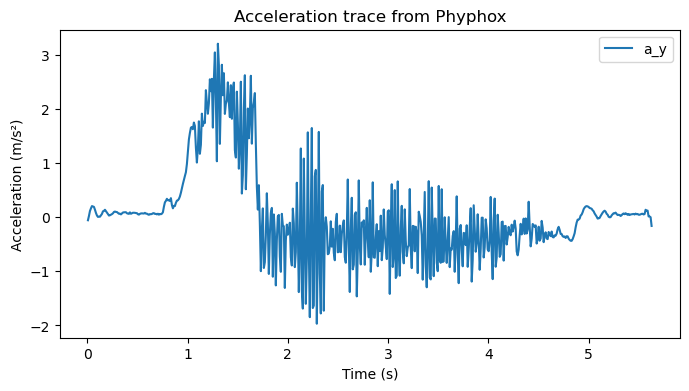

Trial result: a = -0.398 ± 0.632 m/s²
Estimated μ_k = 0.041


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Import data with automatic header detection ---
filename = "Raw Data.csv"
df = pd.read_csv(filename, sep="\t")   # Phyphox export is tab-separated with header in first line

# Print column names so you can see exactly what Phyphox produced
print("Columns in file:", df.columns.tolist())

# --- 2. Extract time and the chosen axis ---
# In this example we assume the y-axis is aligned with motion
time = df[df.columns[0]].values                   # first column should be time
a_y = df[[c for c in df.columns if "y" in c.lower()][0]].values  # auto-detect y-axis column

# --- 3. Plot acceleration vs. time ---
plt.figure(figsize=(8,4))
plt.plot(time, a_y, label="a_y")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Acceleration trace from Phyphox")
plt.legend()
plt.show()

# --- 4. Select a coast interval manually (after inspecting the plot) --- then find mean and sample standard deviation
t_start, t_end = 2.0, 4.0   # <-- adjust for your own data
mask = (time >= t_start) & (time <= t_end)
coast_segment = a_y[mask]

a_mean = np.mean(coast_segment)
a_std = np.std(coast_segment, ddof=1)   # within-trial noise
print(f"Trial result: a = {a_mean:.3f} ± {a_std:.3f} m/s²")

# --- 5. Convert to coefficient of friction ---
g = 9.81
mu = -a_mean / g
print(f"Estimated μ_k = {mu:.3f}")
